# QPD readout from the circuit-QED Hamiltonian

This notebook builds the QPD dispersive-readout theory **starting from the
full qubit–resonator Hamiltonian**, numerically diagonalized in a truncated
joint Hilbert space. We compare it side-by-side against the perturbative
formula (Eqn. 3 of [Serniak et al., PRA 2019](https://arxiv.org/pdf/1903.00113))
already implemented in `qpd.compute_dispersive_matrix(method='perturbative')`,
and use it to extract multi-photon (AC Stark) effects that the perturbative
theory cannot give.

**Outline**

1. Recap: CPB Hamiltonian (matches the existing `qpd.ipynb`).
2. Perturbative dispersive theory (Eqn. 3 of Serniak): what it assumes.
3. Circuit-QED Hamiltonian: full coupling, no dispersive expansion.
4. Joint-space construction, diagonalization, dressed-state labeling.
5. Convergence in qubit and photon truncation.
6. Side-by-side: perturbative vs numerical across $g$.
7. Counter-rotating terms: RWA vs non-RWA.
8. Multi-photon AC Stark: $\chi_i(n)$ and qubit-frequency Stark shifts.


In [1]:
%matplotlib inline
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.lines import Line2D
from qpd import QPD

# WashU design parameters (intermediate E_J/E_C regime)
qpd = QPD(e_j_hz=6.95e9, e_c_hz=0.695e9)
print(f"E_J = {qpd.e_j_hz/1e9:.3f} GHz, E_C = {qpd.e_c_hz/1e9:.3f} GHz")
print(f"E_J/E_C = {qpd.ej_ec_ratio:.2f}  (QPD regime: 10–20)")


E_J = 6.950 GHz, E_C = 0.695 GHz
E_J/E_C = 10.00  (QPD regime: 10–20)


## 1. Recap: Cooper-pair-box Hamiltonian

The bare qubit, in the charge basis $|n\rangle$ (Cooper pairs on the island),
is

$$
\hat{H}_{\mathrm{CPB}}=4 E_C\,(\hat n - n_g)^2 - \tfrac{E_J}{2}\bigl(|n\rangle\langle n+1|+\mathrm{h.c.}\bigr).
$$

Charge parity enters by shifting $n_g \to n_g + \tfrac{1}{2}$ for an odd
quasiparticle on the island. This is exactly what `qpd.solve_eigensystem`
diagonalizes; see `notebooks/qpd.ipynb` for the full derivation. We just
extract the qubit eigenfrequencies and the number operator at the operating
point we'll use later.


In [2]:
ng = 0.25            # operating offset charge (dimensionless, period 1)
parity = 'even'
n_qubit_show = 6

qubit_freqs_hz, n_qubit_mat = qpd._qubit_block_in_eigenbasis(
    ng, parity=parity, n_qubit=n_qubit_show, charge_cutoff=30,
)
print("Qubit eigenfrequencies (relative to ground), GHz:")
print(qubit_freqs_hz / 1e9)


Qubit eigenfrequencies (relative to ground), GHz:
[ 0.          5.39904392  9.67745967 13.40209653 18.56753516 25.35176472]


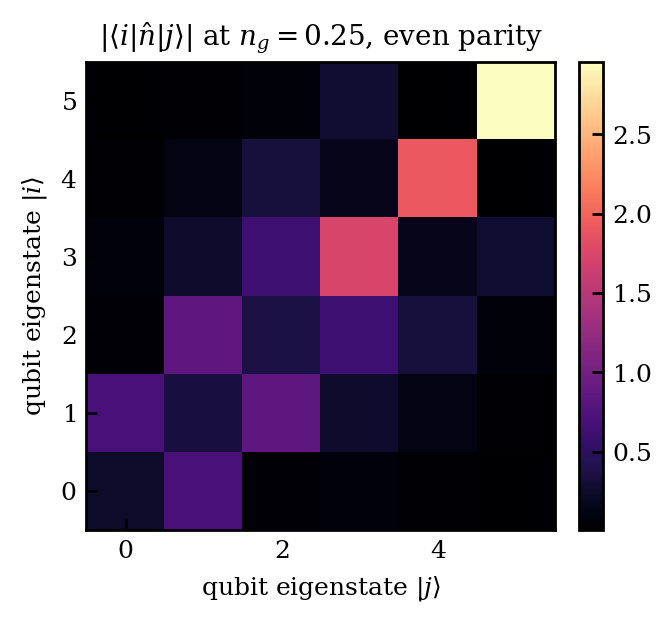

In [3]:
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(3.6, 3))
    im = ax.imshow(np.abs(n_qubit_mat), origin='lower', cmap='magma')
    ax.set_xlabel(r'qubit eigenstate $|j\rangle$')
    ax.set_ylabel(r'qubit eigenstate $|i\rangle$')
    ax.set_title(r'$|\langle i|\hat n|j\rangle|$ at $n_g=0.25$, even parity')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 2. Perturbative theory: Serniak Eqn. 3

The coupling to a single linear readout mode is

$$
\hat H = \hat H_{\mathrm{CPB}} + \hbar\omega_r\,\hat a^\dagger\hat a
        + \hbar g\,\hat n\,(\hat a + \hat a^\dagger).
$$

In the **dispersive regime** $g \ll |\omega_{ij}-\omega_r|$, second-order
perturbation theory in $g$ gives the qubit-state- and parity-dependent
shift

$$
\boxed{\;
\chi_{i,p} = g^2 \sum_{j\neq i}
            \frac{2\,\omega_{ij,p}\,|\langle j,p|\hat n|i,p\rangle|^2}
                 {\omega_{ij,p}^2 - \omega_r^2}.
\;}\qquad(\text{Serniak Eqn.\ 3})
$$

This is **not** the rotating-wave result — the denominator
$\omega_{ij}^2-\omega_r^2 = (\omega_{ij}-\omega_r)(\omega_{ij}+\omega_r)$
keeps the counter-rotating contribution. But it is still only second order
in $g$, and it assumes a single photon in the resonator implicitly (the
shift is taken to be linear in photon number, $\hbar\chi_{i,p}\,\hat a^\dagger\hat a$
in the effective Hamiltonian).

It is the workhorse formula in `qpd.compute_dispersive_matrix(method='perturbative')`.


In [4]:
GHZ = 1e9
MHZ = 1e6

coupling_g_hz = 40e6
readout_freq_hz = 7.0e9
num_levels = 6

mat_pert, chi_pert = qpd.compute_dispersive_matrix(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    num_levels=num_levels,
    parity=parity,
    method='perturbative',
)
print(f"Perturbative chi_i (MHz) for first {num_levels} levels at n_g={ng}:")
for i, chi in enumerate(chi_pert):
    print(f"  chi_{i} = {chi/MHZ:+.4f} MHz")


Perturbative chi_i (MHz) for first 6 levels at n_g=0.25:
  chi_0 = +0.4166 MHz
  chi_1 = -0.2144 MHz
  chi_2 = -0.2958 MHz
  chi_3 = -0.0312 MHz
  chi_4 = +0.0802 MHz
  chi_5 = +0.0226 MHz


## 3. The circuit-QED Hamiltonian, without the dispersive expansion

We keep the **same physical** Hamiltonian as Section 2 but we do **not**
expand in $g/|\Delta|$. Instead we:

1. Truncate the qubit to its lowest $N_q$ eigenstates of
   $\hat H_{\mathrm{CPB}}(n_g, p)$.
2. Truncate the resonator to $N_r$ photons (Fock dimension $N_r+1$).
3. Build the joint matrix

$$
H/h \;=\; \mathrm{diag}(\omega_{q,i})\otimes\mathbb{1}_r
         + \omega_r\,\mathbb{1}_q\otimes \hat a^\dagger\hat a
         + g\,\hat n_q \otimes (\hat a + \hat a^\dagger),
$$

  where $\hat n_q$ is the number operator **projected into the truncated
  qubit eigenbasis**, and $\hat a$ is the standard ladder operator in the
  Fock basis $\langle m|\hat a|m+1\rangle=\sqrt{m+1}$.
4. Diagonalize. The eigenstates are *dressed* states — we label each
   dressed state by the **bare** $|i,n\rangle$ with maximum overlap.

The rotating-wave approximation (RWA) corresponds to keeping only the
co-rotating part of $\hat n(\hat a+\hat a^\dagger)$, i.e. retaining
$\hat n^+\otimes \hat a + \hat n^-\otimes \hat a^\dagger$ where $\hat n^+$
is the upper-triangular (qubit-raising) part of $\hat n$ in the qubit
eigenbasis. The non-RWA Hamiltonian is what we use by default below.

This is implemented in:

- `qpd.build_cqed_hamiltonian(...)` — assemble $H$ in Hz.
- `qpd.solve_cqed_eigensystem(...)` — diagonalize and label dressed states.
- `qpd.compute_dispersive_matrix(..., method='numeric')` — read $\chi_{i,p}$
   from the dressed spectrum:

$$
\chi_{i,p} \;=\; \frac{E(|i,1\rangle) - E(|i,0\rangle)}{h} - \omega_r.
$$

- `qpd.compute_stark_spectrum(...)` — full dressed map for multi-photon
   analysis (Section 8).


In [5]:
n_qubit = 8
n_photon = 5

H_jc, qfreqs, nmat, basis_labels = qpd.build_cqed_hamiltonian(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    parity=parity,
    n_qubit=n_qubit,
    n_photon=n_photon,
    rwa=False,
    return_components=True,
)
print(f"Joint Hilbert space: D = n_qubit * (n_photon+1) = {H_jc.shape[0]}")
print(f"H_jc returned in Hz.")


Joint Hilbert space: D = n_qubit * (n_photon+1) = 48
H_jc returned in Hz.


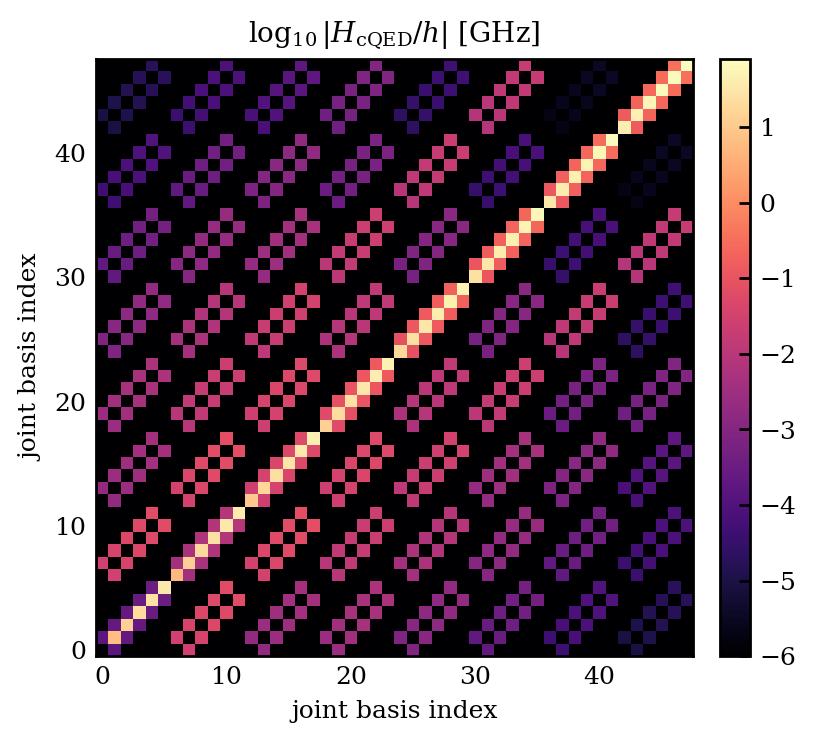

In [6]:
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3.6))
    # Plot |H| in GHz on log scale to see structure
    H_abs = np.abs(H_jc) / GHZ
    im = ax.imshow(np.log10(H_abs + 1e-6), origin='lower', cmap='magma')
    ax.set_title(r'$\log_{10}|H_{\mathrm{cQED}}/h|$ [GHz]')
    ax.set_xlabel('joint basis index')
    ax.set_ylabel('joint basis index')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


### Diagonalization and dressed-state labeling

We diagonalize $H_{\mathrm{cQED}}$ with `scipy.linalg.eigh` (it's real
symmetric — the coupling matrix $\hat n_q$ is real and so are the Fock
operators) and identify each dressed eigenstate with the bare $|i,n\rangle$
that has the largest probability $|\langle i,n|\psi\rangle|^2$. The same
overlap is reported — small overlap is a warning that we are near an
anticrossing where the labeling becomes ambiguous.


In [7]:
dressed_freqs, dressed_vecs, labels, overlaps = qpd.solve_cqed_eigensystem(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    parity=parity,
    n_qubit=n_qubit, n_photon=n_photon, rwa=False,
)

# Show the first few dressed states with their labels
print(f"{'idx':>3}  {'E [GHz]':>10}  {'bare (i,n)':>12}  {'overlap':>8}")
for k in range(min(12, len(dressed_freqs))):
    i, n = labels[k]
    print(f"{k:3d}  {dressed_freqs[k]/GHZ:10.4f}  {(i,n)!s:>12}  {overlaps[k]:8.3f}")

# Health check: smallest overlap
print(f"\nMin overlap across all dressed states: {overlaps.min():.3f}")
print("(values close to 1 indicate clean dispersive labeling)")


idx     E [GHz]    bare (i,n)   overlap
  0     -0.0001        (0, 0)     1.000
  1      5.3985        (1, 0)     1.000
  2      7.0004        (0, 1)     1.000
  3      9.6769        (2, 0)     1.000
  4     12.3982        (1, 1)     0.999
  5     13.4015        (3, 0)     1.000
  6     14.0008        (0, 2)     0.999
  7     16.6766        (2, 1)     1.000
  8     18.5665        (4, 0)     1.000
  9     19.3980        (1, 2)     0.999
 10     20.4015        (3, 1)     0.999
 11     21.0012        (0, 3)     0.999

Min overlap across all dressed states: 0.996
(values close to 1 indicate clean dispersive labeling)


## 4. Convergence in qubit and photon truncation

The truncations $N_q$ and $N_r$ are knobs. We check $\chi_{0}$ and $\chi_{1}$
converge as we raise them.


In [8]:
configs = [(4, 2), (6, 3), (8, 4), (10, 5), (12, 8), (14, 10)]
rows = []
for nq, npt in configs:
    _, chi = qpd.compute_dispersive_matrix(
        ng, coupling_g_hz, readout_freq_hz,
        num_levels=4, parity=parity,
        method='numeric', n_qubit=nq, n_photon=npt,
    )
    rows.append((nq, npt, chi[0], chi[1], chi[2], chi[3]))

print(f"{'n_q':>4} {'n_ph':>5} {'chi_0':>10} {'chi_1':>10} {'chi_2':>10} {'chi_3':>10}  [MHz]")
for nq, npt, c0, c1, c2, c3 in rows:
    print(f"{nq:4d} {npt:5d} {c0/MHZ:10.5f} {c1/MHZ:10.5f} {c2/MHZ:10.5f} {c3/MHZ:10.5f}")


 n_q  n_ph      chi_0      chi_1      chi_2      chi_3  [MHz]
   4     2    0.41658   -0.21031   -0.18796   -0.01689
   6     3    0.41649   -0.21409   -0.29571   -0.03149
   8     4    0.41649   -0.21410   -0.29576   -0.03152
  10     5    0.41649   -0.21410   -0.29576   -0.03152
  12     8    0.41649   -0.21410   -0.29576   -0.03152
  14    10    0.41649   -0.21410   -0.29576   -0.03152


Defaults of `n_qubit=8`, `n_photon=5` already give ~6-digit agreement
with much larger truncations at this $g$. As $g$ grows, more photon levels
are needed (the dressed states acquire more bare-Fock content).


## 5. Side-by-side: perturbative vs numerical across $g$

In the small-$g$ limit, the numerical result must reproduce Eqn. 3 of Serniak
(both keep counter-rotating terms; the numerical diagonalization just goes to higher order in $g$ via
the dressed diagonalization). At larger $g$, the two diverge in a
well-defined way.


In [9]:
g_list_mhz = np.array([1, 5, 10, 20, 40, 80, 150, 250, 400])
chi0_pert = np.empty_like(g_list_mhz, dtype=float)
chi0_num = np.empty_like(g_list_mhz, dtype=float)
chi1_pert = np.empty_like(g_list_mhz, dtype=float)
chi1_num = np.empty_like(g_list_mhz, dtype=float)

for k, g_mhz in enumerate(g_list_mhz):
    _, chi_p = qpd.compute_dispersive_matrix(
        ng, g_mhz*MHZ, readout_freq_hz, num_levels=4, parity=parity,
        method='perturbative',
    )
    _, chi_j = qpd.compute_dispersive_matrix(
        ng, g_mhz*MHZ, readout_freq_hz, num_levels=4, parity=parity,
        method='numeric', n_qubit=12, n_photon=8,
    )
    chi0_pert[k] = chi_p[0]
    chi0_num[k] = chi_j[0]
    chi1_pert[k] = chi_p[1]
    chi1_num[k] = chi_j[1]


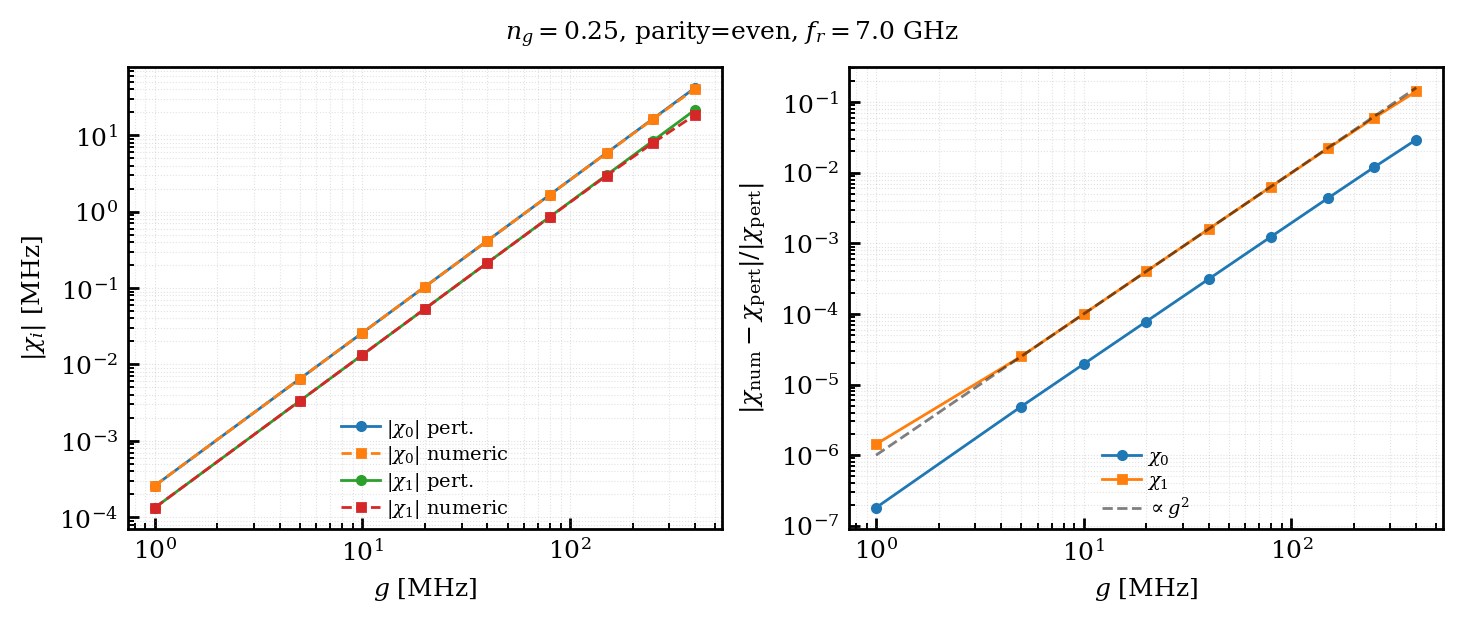

In [10]:
with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3))

    ax1.loglog(g_list_mhz, np.abs(chi0_pert)/MHZ, 'o-', label=r'$|\chi_0|$ pert.')
    ax1.loglog(g_list_mhz, np.abs(chi0_num)/MHZ, 's--', label=r'$|\chi_0|$ numeric')
    ax1.loglog(g_list_mhz, np.abs(chi1_pert)/MHZ, 'o-', label=r'$|\chi_1|$ pert.')
    ax1.loglog(g_list_mhz, np.abs(chi1_num)/MHZ, 's--', label=r'$|\chi_1|$ numeric')
    ax1.set_xlabel(r'$g$ [MHz]')
    ax1.set_ylabel(r'$|\chi_i|$ [MHz]')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3, which='both')

    rel0 = np.abs((chi0_num - chi0_pert) / chi0_pert)
    rel1 = np.abs((chi1_num - chi1_pert) / chi1_pert)
    ax2.loglog(g_list_mhz, rel0, 'o-', label=r'$\chi_0$')
    ax2.loglog(g_list_mhz, rel1, 's-', label=r'$\chi_1$')
    # Reference slope-2 (next-order PT in g) and slope-4 lines
    ax2.loglog(g_list_mhz, 1e-6*g_list_mhz**2, 'k--', alpha=0.5, label=r'$\propto g^2$')
    ax2.set_xlabel(r'$g$ [MHz]')
    ax2.set_ylabel(r'$|\chi_\mathrm{num} - \chi_\mathrm{pert}|/|\chi_\mathrm{pert}|$')
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3, which='both')
    fig.suptitle(f'$n_g={ng}$, parity={parity}, $f_r={readout_freq_hz/GHZ:.1f}$ GHz', fontsize=9)


**Reading the right panel.** The relative deviation grows like $g^2$
(power-counting: the next term beyond the second-order PT is $\mathcal{O}(g^4)$
in $\chi$, which is $\mathcal{O}(g^2)$ relative to $\chi\sim g^2$). At
$g\lesssim 40$ MHz (typical) the two theories agree to ~1%; at $g \gtrsim 200$
MHz the perturbative formula is no longer trustworthy and the numerical diagonalization is the right
tool.


### $\chi$ vs offset charge: side-by-side curves


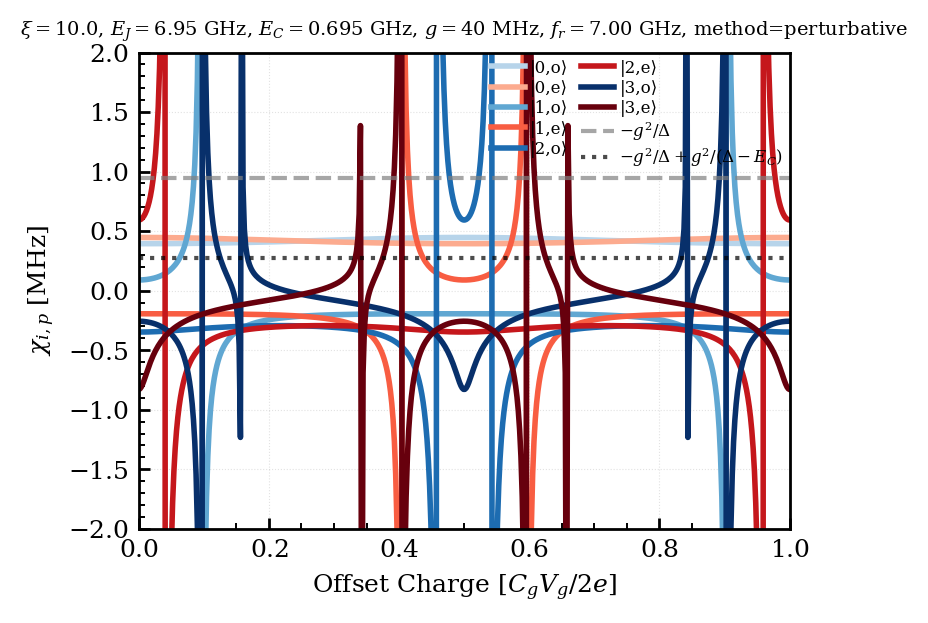

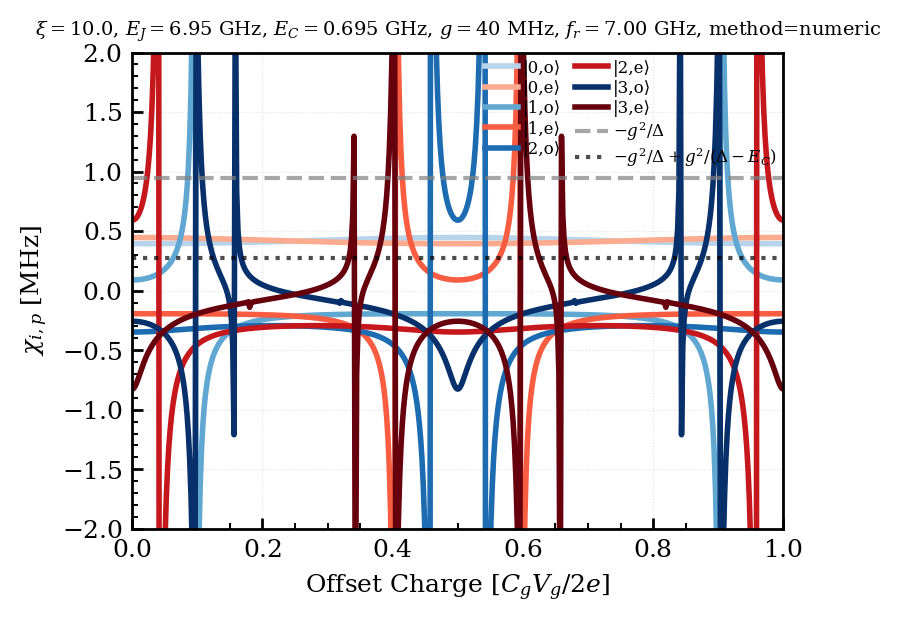

In [11]:
# Use built-in plotter, dispatching on method=
fig_p, ax_p = qpd.plot_dispersive_shift(
    coupling_g_hz=40e6, readout_freq_hz=7e9,
    method='perturbative',
    ylim=[-2, 2]
)
fig_j, ax_j = qpd.plot_dispersive_shift(
    coupling_g_hz=40e6, readout_freq_hz=7e9,
    method='numeric', n_qubit=10, n_photon=5,
    ylim=[-2, 2]
)
plt.show()


## 6. Counter-rotating terms: full vs RWA

Eqn. 3 of Serniak is **not** an RWA result — it keeps both
$\omega_{ij}-\omega_r$ and $\omega_{ij}+\omega_r$ in the denominator. To
see this explicitly we compare:

- `method='numeric'`, `rwa=False` (default) — full $\hat n(\hat a+\hat a^\dagger)$;
  reduces to Eqn. 3 in the $g\to 0$ limit.
- `method='numeric'`, `rwa=True` — drops the counter-rotating
  $\hat n^+ \hat a^\dagger + \hat n^- \hat a$ terms; this corresponds to
  the Jaynes–Cummings (RWA) limit. It misses the Bloch–Siegert shift
  $\sim g^2/(\omega_{ij}+\omega_r)$, which for QPD with $\omega_{01}\sim 6$
  GHz and $\omega_r\sim 7$ GHz is comparable in size to the resonant
  contribution.


In [12]:
_, chi_p = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='perturbative')
_, chi_full = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='numeric', n_qubit=10, n_photon=5, rwa=False)
_, chi_rwa = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='numeric', n_qubit=10, n_photon=5, rwa=True)

print("chi_i in MHz (i=0..3):")
print(f"  Serniak Eqn.3  : {chi_p[:4]/MHZ}")
print(f"  full (no RWA): {chi_full[:4]/MHZ}")
print(f"  RWA (Jaynes–Cummings)       : {chi_rwa[:4]/MHZ}")
print()
print("Bloch-Siegert-like piece (full − RWA), MHz:")
print(f"  {(chi_full - chi_rwa)[:4] / MHZ}")


chi_i in MHz (i=0..3):
  Serniak Eqn.3  : [ 0.41661866 -0.21444015 -0.29579395 -0.03117823]
  full (no RWA): [ 0.4164886  -0.21409749 -0.2957592  -0.03151633]
  RWA (Jaynes–Cummings)       : [-0.06282956 -0.04593424  0.03369772  0.05307144]

Bloch-Siegert-like piece (full − RWA), MHz:
  [ 0.47931816 -0.16816325 -0.32945692 -0.08458777]


## 7. Multi-photon AC Stark shifts

The circuit-QED diagonalization gives us the **entire** dressed spectrum $E(|i,n\rangle)$,
not just the single-photon dispersive shift. We expose two photon-number-resolved
quantities via `qpd.compute_stark_spectrum`:

- **Photon-number-dependent dispersive shift**

  $$ \chi_i(n) \;=\; \bigl[E(|i,n+1\rangle) - E(|i,n\rangle)\bigr] - \omega_r,$$

  i.e. the resonator transition frequency from $n$ to $n+1$ photons when
  the qubit sits in dressed $|i\rangle$. For $n=0$ this matches the
  single-photon $\chi_{i,p}$ above.

- **AC Stark shift on qubit transitions**

  $$ \Delta\omega_{0i}(n) \;=\; [E(|i,n\rangle)-E(|0,n\rangle)] - [E(|i,0\rangle)-E(|0,0\rangle)],$$

  i.e. how much the qubit $|0\rangle\to|i\rangle$ transition shifts when the
  resonator is populated with $n$ photons.

Neither is accessible from Eqn. 3 directly — it assumed the resonator
appears only in the $\hat a^\dagger\hat a$ form, i.e. it linearized the
photon-number dependence by construction.


In [13]:
g_test = 80e6  # large coupling makes effects visible

dressed, chi_n, qubit_stark = qpd.compute_stark_spectrum(
    offset_charge=ng,
    coupling_g_hz=g_test,
    readout_freq_hz=readout_freq_hz,
    num_levels=4,
    parity=parity,
    n_qubit=15, n_photon=100, rwa=False,
)
print(f"chi_n shape: {chi_n.shape}  (levels × n_photon)")
print(f"qubit_stark shape: {qubit_stark.shape}  (levels × (n_photon+1))")


chi_n shape: (4, 100)  (levels × n_photon)
qubit_stark shape: (4, 101)  (levels × (n_photon+1))


/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2792852378.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


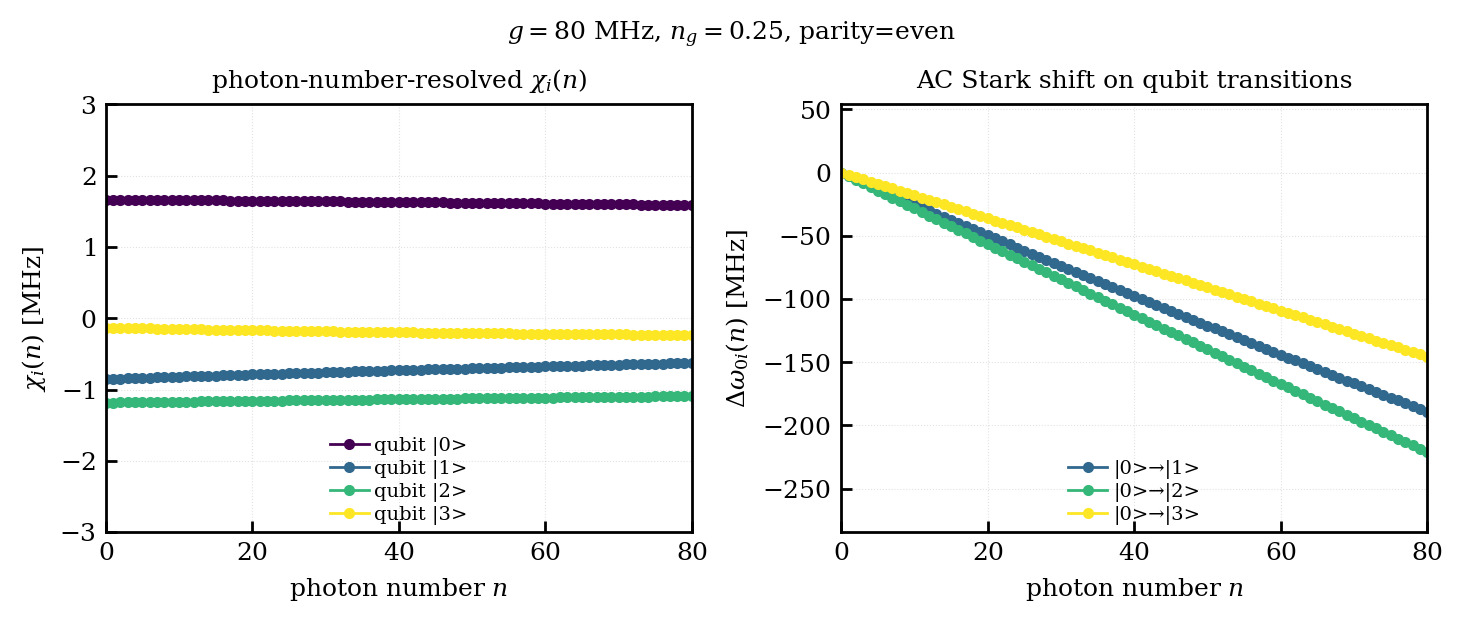

In [14]:
# Drop the topmost photon column for chi_n — it is asymmetrically dressed
# at the Fock truncation edge and not physical
n_safe = chi_n.shape[1] - 1
photons = np.arange(n_safe)

with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3))

    cmap = cm.get_cmap('viridis')
    for i in range(chi_n.shape[0]):
        ax1.plot(photons, chi_n[i, :n_safe]/MHZ, 'o-',
                 color=cmap(i / max(chi_n.shape[0]-1, 1)),
                 label=f'qubit |{i}>')
    ax1.set_xlabel('photon number $n$')
    ax1.set_ylabel(r'$\chi_i(n)$ [MHz]')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0, 80)
    ax1.set_ylim(-3, 3)
    ax1.set_title(r'photon-number-resolved $\chi_i(n)$', fontsize=9)

    for i in range(1, qubit_stark.shape[0]):
        ax2.plot(np.arange(qubit_stark.shape[1]),
                 qubit_stark[i] / MHZ, 'o-',
                 color=cmap(i / max(qubit_stark.shape[0]-1, 1)),
                 label=f'|0>→|{i}>')
    ax2.set_xlim(0, 80)
    ax2.set_xlabel('photon number $n$')
    ax2.set_ylabel(r'$\Delta\omega_{0i}(n)$ [MHz]')
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3)
    ax2.set_title('AC Stark shift on qubit transitions', fontsize=9)
    fig.suptitle(f'$g={g_test/MHZ:.0f}$ MHz, $n_g={ng}$, parity={parity}', fontsize=9)
plt.show()


**Interpretation.** The slope $\partial\chi_i/\partial n$ is the
**Kerr** (photon-photon) nonlinearity inherited from qubit-induced
anharmonicity of the dressed resonator. The AC Stark slope
$\partial \Delta\omega_{0i}/\partial n$ is the textbook Stark shift
$2\chi$ to leading order, but here it includes higher-order corrections
that come from the full diagonalization.


## 8. When the perturbative formula breaks down

Two practical signals that Eqn. 3 is no longer reliable, both visible
straight from the circuit-QED diagonalization:

1. **Dressed-state overlap drops well below 1.** Near a qubit–resonator
   anticrossing the labeling becomes ambiguous — that is exactly the
   physical regime where perturbation theory diverges.
2. **$|\chi_\mathrm{num} - \chi_\mathrm{pert}|/|\chi_\mathrm{pert}|$ is no
   longer small** at the operating $g$.

The cell below sweeps the resonator frequency through the qubit
transitions and shows where dressed-state overlaps collapse.


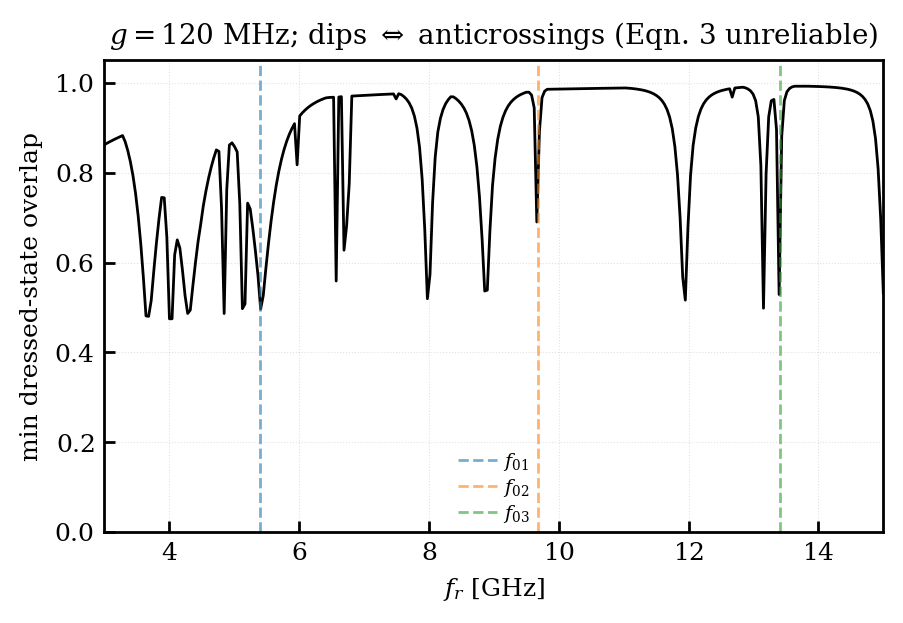

In [15]:
f_r_scan = np.linspace(3e9, 15e9, 300)
min_overlap = []
for f_r in f_r_scan:
    _, _, _, ov = qpd.solve_cqed_eigensystem(
        ng, coupling_g_hz=120e6, readout_freq_hz=f_r,
        parity=parity, n_qubit=8, n_photon=4, rwa=False,
    )
    min_overlap.append(ov.min())

# Mark qubit transition frequencies
qfreqs, _ = qpd._qubit_block_in_eigenbasis(ng, parity=parity, n_qubit=4)
f_qubit = qfreqs[1:] - qfreqs[0]

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4.4, 3))
    ax.plot(f_r_scan/GHZ, min_overlap, 'k-')
    for k, f_q in enumerate(f_qubit):
        ax.axvline(f_q/GHZ, color=f'C{k}', linestyle='--', alpha=0.6,
                   label=fr'$f_{{0{k+1}}}$')
    ax.set_xlabel(r'$f_r$ [GHz]')
    ax.set_ylabel('min dressed-state overlap')
    ax.set_title(r'$g=120$ MHz; dips $\Leftrightarrow$ anticrossings (Eqn. 3 unreliable)')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(f_r_scan[0]/GHZ, f_r_scan[-1]/GHZ)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.show()


## 9. Per-parity dispersive shift vs offset charge, photon-number-resolved

A device-design question Eqn. 3 cannot answer: *how does each parity's
dispersive shift $\chi_{0,p}(n_g)$ evolve as we drive more photons into the
resonator?* The single-photon answer ($n=0$) is what the perturbative formula
returns; the circuit-QED diagonalization gives $\chi_0(n)$ separately for each photon
number through `compute_stark_spectrum`.

We sweep $n_g$ over one period at a fixed resonator frequency $f_r=6.936$ GHz
(WashU device; configurable below) and plot **each parity separately** —
$\chi_{0,e}$ (blue) and $\chi_{0,o}$ (red) — with one curve per photon number,
shaded so darker means more photons (grayscale colorbar). The sharp downward
spikes are multi-photon anticrossings, where bare $|0,n\rangle$ stops being a
clean eigenstate and readout becomes ill-defined at that $(n_g, n)$.

In [16]:
# --- configurable inputs ---
RESONATOR_FREQ_HZ = 6.936e9         # WashU resonator (change to your device)
COUPLING_G_HZ_S9 = 40e6             # WashU readout coupling (matches qpd.ipynb)
N_QUBIT_S9 = 15
N_PHOTON_S9 = 50                   # we'll trust photon indices < N_PHOTON_S9 - 5
N_NG = 201

ng_grid = np.linspace(0, 1, N_NG)
chi0_even = np.zeros((N_NG, N_PHOTON_S9))
chi0_odd  = np.zeros((N_NG, N_PHOTON_S9))

# Use the static (max-overlap, bare-state) labeling:
#   chi_0,p(n_g, n) = dispersive shift extracted from the dressed state with
#   maximum overlap on bare |0, n>.
# Spikes mark where bare |0, n> stops being a clean energy eigenstate (i.e.
# multi-photon anticrossings) — exactly the n_g values where readout
# becomes ill-defined.  The spike height is the anticrossing gap.
# (`compute_stark_sweep_adiabatic` is the alternative — it follows each
# dressed branch through anticrossings, which gives smooth curves but the
# branch's bare-state identity swaps across each resonance, so the resulting
# chi_o - chi_e loses its parity-readout interpretation past the first
# resonance.)
for k, ng_val in tqdm(enumerate(ng_grid), total=N_NG):
    _, cn_e, _ = qpd.compute_stark_spectrum(
        offset_charge=ng_val,
        coupling_g_hz=COUPLING_G_HZ_S9,
        readout_freq_hz=RESONATOR_FREQ_HZ,
        num_levels=1, parity='even',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False,
        charge_cutoff=31,
    )
    _, cn_o, _ = qpd.compute_stark_spectrum(
        offset_charge=ng_val,
        coupling_g_hz=COUPLING_G_HZ_S9,
        readout_freq_hz=RESONATOR_FREQ_HZ,
        num_levels=1, parity='odd',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False,
        charge_cutoff=31,
    )
    chi0_even[k] = cn_e[0]
    chi0_odd[k]  = cn_o[0]

print(f"computed chi_0,e and chi_0,o at f_r={RESONATOR_FREQ_HZ/GHZ:.3f} GHz, "
      f"g={COUPLING_G_HZ_S9/MHZ:.0f} MHz over {N_NG} n_g points and "
      f"{N_PHOTON_S9} photon-number bins.")


100%|██████████| 201/201 [00:34<00:00,  5.84it/s]

computed chi_0,e and chi_0,o at f_r=6.936 GHz, g=40 MHz over 201 n_g points and 50 photon-number bins.


/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2425702095.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_even = cm.get_cmap('Blues')
/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2425702095.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_odd  = cm.get_cmap('Reds')
/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2425702095.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = cm.ScalarMa

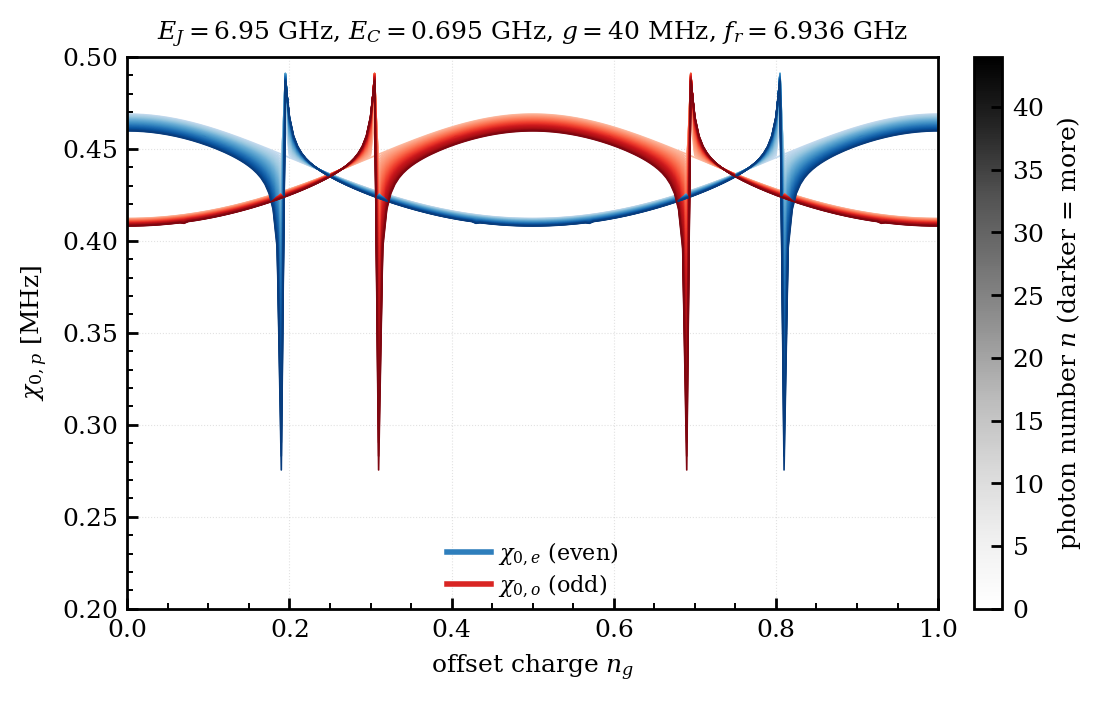

In [17]:
# Drop the topmost photon columns — dressed against the Fock truncation edge.
n_max_safe = N_PHOTON_S9 - 5

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    cmap_even = cm.get_cmap('Blues')
    cmap_odd  = cm.get_cmap('Reds')

    # One curve per photon number for each parity; shade encodes n
    # (darker = more photons). Even = blue, odd = red.
    for n in range(n_max_safe):
        shade = 0.25 + 0.7 * n / max(n_max_safe - 1, 1)
        ax.plot(ng_grid, chi0_even[:, n] / MHZ, color=cmap_even(shade), lw=0.6)
        ax.plot(ng_grid, chi0_odd[:, n]  / MHZ, color=cmap_odd(shade),  lw=0.6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.2, 0.5)
    ax.set_xlabel(r'offset charge $n_g$')
    ax.set_ylabel(r'$\chi_{0,p}$ [MHz]')
    title_parts = [
        f'$E_J={qpd.e_j_hz/GHZ:.2f}$ GHz',
        f'$E_C={qpd.e_c_hz/GHZ:.3f}$ GHz',
        f'$g={COUPLING_G_HZ_S9/MHZ:.0f}$ MHz',
        f'$f_r={RESONATOR_FREQ_HZ/GHZ:.3f}$ GHz',
    ]
    ax.set_title(', '.join(title_parts), fontsize=9)
    ax.minorticks_on()
    ax.grid(alpha=0.3)

    # Grayscale colorbar for the photon-number shading.
    sm = cm.ScalarMappable(cmap=cm.get_cmap('Greys'),
                           norm=mpl.colors.Normalize(0, n_max_safe - 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'photon number $n$ (darker = more)')

    # Legend: one proxy line per parity.
    handles = [
        Line2D([0], [0], color=cmap_even(0.7), lw=2, label=r'$\chi_{0,e}$ (even)'),
        Line2D([0], [0], color=cmap_odd(0.7),  lw=2, label=r'$\chi_{0,o}$ (odd)'),
    ]
    ax.legend(handles=handles, loc='lower center', fontsize=8)
plt.show()


## 10. From $\chi_{0,p}$ to the observed transmission peak

Every $\chi_{0,p}$ above is read off a dressed-state **label**: the shift
$\chi_{0,p}=[E(\text{dressed }|0,1\rangle)-E(\text{dressed }|0,0\rangle)]-\omega_r$,
where “dressed $|0,n\rangle$” is the full-Hamiltonian eigenstate assigned by
maximum overlap to the bare *qubit-ground $\otimes$ $n$-photon* state. That
label is not directly what a transmission measurement returns. The feedline
sits at the resonator and couples to the **bare** field $\hat a+\hat a^\dagger$,
and near a qubit–resonator anticrossing the label assumption breaks three ways:

1. **No unique one-photon state** — the photon character splits across two
   eigenstates (a vacuum-Rabi doublet).
2. **The labeled state may be invisible** — if it is mostly qubit-like (low
   photon weight) it barely appears in transmission, so $\chi_{0,p}$ points at
   a peak that isn't there.
3. **The label can jump** — the Hungarian assignment can swap branches
   discontinuously in $n_g$, an artifact no instrument sees.

So $\chi_{0,p}(n_g)$ is a property of the spectrum's *labeling*, not of the
*measurement*. Let's build the label-free observable and see where they agree.

In [18]:
# f_10 has charge dispersion; placing f_r inside that band forces a
# qubit-resonator resonance (anticrossing) somewhere in n_g in [0, 1].
g = COUPLING_G_HZ_S9                      # WashU readout coupling (40 MHz)
fr_disp = RESONATOR_FREQ_HZ              # far detuned -> true dispersive regime

f10_0  = np.diff(qpd.solve_eigensystem(0.0)[0][:2])[0] / qpd.PLANCK_EV_S
f10_05 = np.diff(qpd.solve_eigensystem(0.5)[0][:2])[0] / qpd.PLANCK_EV_S
fr_resonant = 0.5 * (f10_0 + f10_05)     # sits in the f_10 band -> crossing
print(f"f10(ng=0)={f10_0/GHZ:.3f} GHz, f10(ng=0.5)={f10_05/GHZ:.3f} GHz")
print(f"dispersive f_r = {fr_disp/GHZ:.3f} GHz   |   "
      f"resonant f_r = {fr_resonant/GHZ:.3f} GHz   |   g = {g/1e6:.0f} MHz")

f10(ng=0)=5.490 GHz, f10(ng=0.5)=5.316 GHz
dispersive f_r = 6.936 GHz   |   resonant f_r = 5.403 GHz   |   g = 40 MHz


### What transmission actually measures

Because the line couples to the bare field, weak-probe transmission is set by
the **resonator response function**

$$S(\omega)\;\propto\;\sum_f \big|\langle f|\,\hat a+\hat a^\dagger\,|i\rangle\big|^2\;
\mathcal{L}_\kappa\!\big(\omega-(E_f-E_i)\big),$$

with $\{|f\rangle,E_f\}$ the eigenstates of the **full** hybridized Hamiltonian
(no labeling) and $|i\rangle$ the populated initial state (qubit ground, $\bar n$
photons). Peaks sit at the *dressed* transitions $E_f-E_i$, weighted by the
bare-photon matrix element — a transition is visible only insofar as it carries
photon character. The observed shift is $\chi_{\rm obs}=f_{\rm peak}-\omega_r$.
`compute_transmission_spectrum` returns this, label-free, with diagnostics.

In [19]:
def show(res, fr, tag):
    print(f"{tag}:")
    print(f"  dominant chi_obs = {res['dominant_chi_hz']/1e6:8.3f} MHz"
          f"   weight fraction = {res['dominant_weight_frac']:.3f}")
    print(f"  # peaks = {res['n_significant_peaks']}"
          f"   crossing_detected = {res['crossing_detected']}"
          f"   converged = {res['converged']}")
    print("  peaks (f - f_r) [MHz] / weight:",
          [(round((f - fr)/1e6, 2), round(w, 3))
           for f, w in zip(res['peaks_hz'], res['weights'])])
    print()

# (a) Dispersive readout at the sweet spot: one clean peak (chi_obs = label chi).
show(qpd.compute_transmission_spectrum(0.5, g, fr_disp, parity='odd', n_bar=0),
     fr_disp, "dispersive, ng=0.5, odd")

# (b) Resonant readout near the crossing: the response splits into a doublet.
show(qpd.compute_transmission_spectrum(0.2, g, fr_resonant, parity='odd', n_bar=0),
     fr_resonant, "resonant, ng=0.2, odd  (vacuum-Rabi doublet)")

dispersive, ng=0.5, odd:
  dominant chi_obs =    0.469 MHz   weight fraction = 1.000
  # peaks = 1   crossing_detected = False   converged = True
  peaks (f - f_r) [MHz] / weight: [(np.float64(0.47), np.float64(1.0))]

resonant, ng=0.2, odd  (vacuum-Rabi doublet):
  dominant chi_obs =   16.435 MHz   weight fraction = 0.737
  # peaks = 2   crossing_detected = True   converged = True
  peaks (f - f_r) [MHz] / weight: [(np.float64(16.44), np.float64(0.737)), (np.float64(-46.9), np.float64(0.263))]



### Observed $\chi_{0,p}(n_g)$ per parity, photon-number-resolved

The same view as Section 9 — $\chi_{0,e}$ (blue) and $\chi_{0,o}$ (red), one
curve per photon number, shaded darker = more — but built from the
**observed**, label-free peak (`compute_observed_chi_spectrum`) instead of the
bare-state label. Same device parameters ($f_r=6.936$ GHz, $g=40$ MHz) as
Section 9, so the two figures overlay directly.

The sharp spikes are **multi-photon anticrossings**: at high photon number the
bright resonator transition $|0,n\rangle\to|0,n{+}1\rangle$ is pushed in
frequency because $|0,n{+}1\rangle$ hybridizes with a *dark* state $|j,m\rangle$
that carries no resonator-probe weight. So the observed peak **shifts** toward
the bare cavity ($\chi$ collapses) but stays *single* — it does **not** split,
and `crossing` does not fire here. A genuine doublet needs a *transverse*
(vacuum-Rabi) resonance — $f_r$ near a qubit transition, where the bright
excitation itself is degenerate — demonstrated in Section 11.

In [20]:
# Observed (label-free) chi_0,p(n_g, n) at the SAME device params as Sec. 9,
# from compute_observed_chi_spectrum (dominant transmission peak per photon
# number). One eigensolve per (n_g, parity) yields every photon number.
chi_obs_even = np.full((N_NG, N_PHOTON_S9), np.nan)
chi_obs_odd  = np.full((N_NG, N_PHOTON_S9), np.nan)
cross_even   = np.zeros((N_NG, N_PHOTON_S9), dtype=bool)
cross_odd    = np.zeros((N_NG, N_PHOTON_S9), dtype=bool)

for k, ng_val in tqdm(enumerate(ng_grid), total=N_NG):
    ce, xe, _ = qpd.compute_observed_chi_spectrum(
        ng_val, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, parity='even',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False, charge_cutoff=31)
    co, xo, _ = qpd.compute_observed_chi_spectrum(
        ng_val, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, parity='odd',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False, charge_cutoff=31)
    chi_obs_even[k] = ce; chi_obs_odd[k] = co
    cross_even[k] = xe;  cross_odd[k] = xo

n_flagged = int(cross_even.sum() + cross_odd.sum())
print(f"observed chi_0,e and chi_0,o at f_r={RESONATOR_FREQ_HZ/GHZ:.3f} GHz, "
      f"g={COUPLING_G_HZ_S9/MHZ:.0f} MHz over {N_NG} n_g x {N_PHOTON_S9} photons; "
      f"{n_flagged} (n_g, n) points flagged as peak-split crossings.")

100%|██████████| 201/201 [00:35<00:00,  5.73it/s]

observed chi_0,e and chi_0,o at f_r=6.936 GHz, g=40 MHz over 201 n_g x 50 photons; 0 (n_g, n) points flagged as peak-split crossings.


/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2863981189.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_even = cm.get_cmap('Blues')
/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2863981189.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_odd  = cm.get_cmap('Reds')
/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2863981189.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = cm.ScalarMa

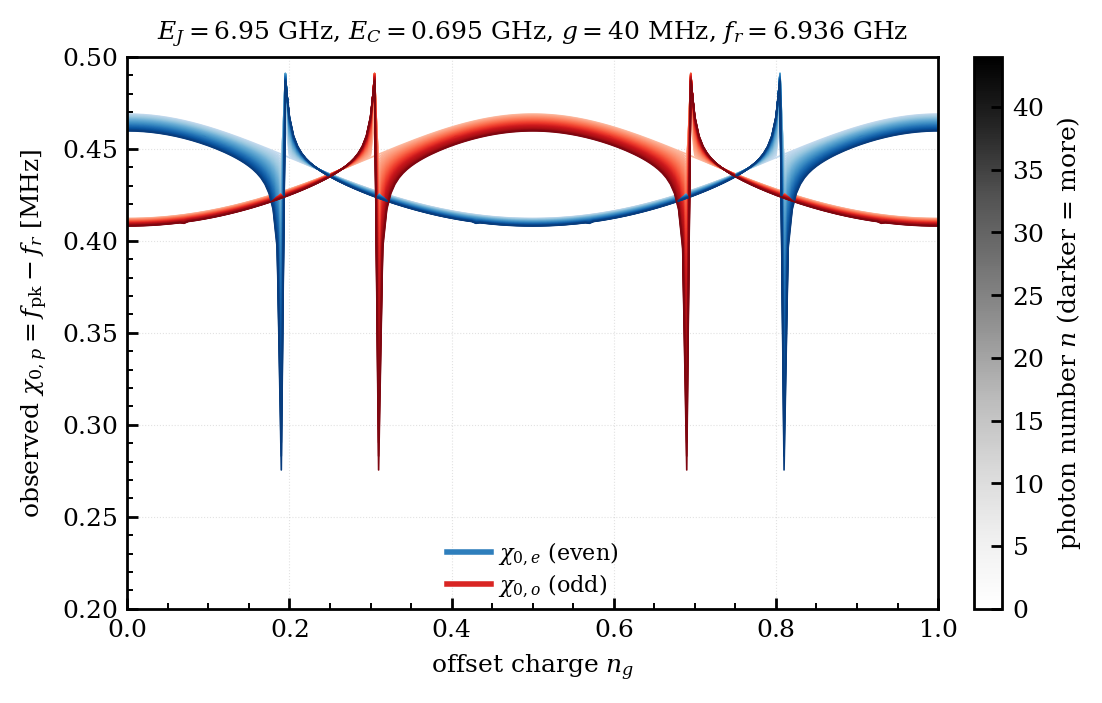

In [21]:
# Same per-parity, photon-shaded style as Sec. 9, but the *observed* peak.
n_max_safe = N_PHOTON_S9 - 5

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    cmap_even = cm.get_cmap('Blues')
    cmap_odd  = cm.get_cmap('Reds')

    for n in range(n_max_safe):
        shade = 0.25 + 0.7 * n / max(n_max_safe - 1, 1)
        ax.plot(ng_grid, chi_obs_even[:, n] / MHZ, color=cmap_even(shade), lw=0.6)
        ax.plot(ng_grid, chi_obs_odd[:, n]  / MHZ, color=cmap_odd(shade),  lw=0.6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.2, 0.5)
    ax.set_xlabel(r'offset charge $n_g$')
    ax.set_ylabel(r'observed $\chi_{0,p}=f_{\rm pk}-f_r$ [MHz]')
    title_parts = [
        f'$E_J={qpd.e_j_hz/GHZ:.2f}$ GHz',
        f'$E_C={qpd.e_c_hz/GHZ:.3f}$ GHz',
        f'$g={COUPLING_G_HZ_S9/MHZ:.0f}$ MHz',
        f'$f_r={RESONATOR_FREQ_HZ/GHZ:.3f}$ GHz',
    ]
    ax.set_title(', '.join(title_parts), fontsize=9)
    ax.minorticks_on()
    ax.grid(alpha=0.3)

    sm = cm.ScalarMappable(cmap=cm.get_cmap('Greys'),
                           norm=mpl.colors.Normalize(0, n_max_safe - 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'photon number $n$ (darker = more)')

    handles = [
        Line2D([0], [0], color=cmap_even(0.7), lw=2, label=r'$\chi_{0,e}$ (even)'),
        Line2D([0], [0], color=cmap_odd(0.7),  lw=2, label=r'$\chi_{0,o}$ (odd)'),
    ]
    ax.legend(handles=handles, loc='lower center', fontsize=8)
plt.show()

### Power dependence: the figure above is the dispersive operating point

The figure above already shows the full photon-number dependence of the
**observed** shift at the dispersive readout — a gentle, smooth drift with $n$
(the resonator rungs are nearly harmonic there). Near a qubit–resonator
crossing the story changes: the shift swings strongly with photon number and
the critical photon number $n_{\rm crit}$ collapses, so the low-$n$ prediction
is not where you read out at finite power. The scan below contrasts the two
(odd parity).

In [22]:
print("dominant chi_obs(n_bar) [MHz], odd parity")
print("  dispersive f_r, ng=0.5  (gentle AC-Stark drift):")
for nb_ in range(0, 6):
    r = qpd.compute_transmission_spectrum(0.5, g, fr_disp, parity='odd',
                                          n_bar=nb_, n_photon=nb_ + 4,
                                          check_convergence=False)
    print(f"    n_bar={nb_}: chi_obs={r['dominant_chi_hz']/1e6:8.3f} MHz"
          f"  frac={r['dominant_weight_frac']:.3f}")

print("  near crossing (resonant f_r), ng=0.2  (strong power dependence):")
for nb_ in range(0, 6):
    r = qpd.compute_transmission_spectrum(0.2, g, fr_resonant, parity='odd',
                                          n_bar=nb_, n_photon=nb_ + 4,
                                          check_convergence=False)
    print(f"    n_bar={nb_}: chi_obs={r['dominant_chi_hz']/1e6:8.3f} MHz"
          f"  frac={r['dominant_weight_frac']:.3f}  cross={r['crossing_detected']}")

dominant chi_obs(n_bar) [MHz], odd parity
  dispersive f_r, ng=0.5  (gentle AC-Stark drift):
    n_bar=0: chi_obs=   0.469 MHz  frac=1.000
    n_bar=1: chi_obs=   0.469 MHz  frac=1.000
    n_bar=2: chi_obs=   0.468 MHz  frac=1.000
    n_bar=3: chi_obs=   0.468 MHz  frac=1.000
    n_bar=4: chi_obs=   0.468 MHz  frac=1.000
    n_bar=5: chi_obs=   0.468 MHz  frac=1.000
  near crossing (resonant f_r), ng=0.2  (strong power dependence):
    n_bar=0: chi_obs=  16.435 MHz  frac=0.737  cross=True
    n_bar=1: chi_obs=  10.751 MHz  frac=0.956  cross=False
    n_bar=2: chi_obs=   8.685 MHz  frac=0.983  cross=False
    n_bar=3: chi_obs=   7.514 MHz  frac=0.991  cross=False
    n_bar=4: chi_obs=   6.733 MHz  frac=0.995  cross=False
    n_bar=5: chi_obs=   6.163 MHz  frac=0.997  cross=False


### Caveats baked into the diagnostics

* **Linear response / low power.** This is the single-quantum response from
  $|i\rangle$; the high-power operating-point spectrum near a crossing needs a
  driven steady state (input–output / Lindblad), beyond this linear $\chi_{aa}$.
* **Gauge ambiguity at near-degeneracy.** When two peaks split by less than
  $\kappa$, the *individual* weights are basis-gauge dependent; only the
  $\kappa$-broadened sum is invariant. Treat `crossing_detected` as “don't trust
  a single number here.”
* **Truncation.** Near a crossing the weight spreads and $\hat a+\hat a^\dagger$
  clips at the top Fock rung; `check_convergence=True` re-checks at larger
  $(n_{\rm qubit}, n_{\rm photon})$ and sets `converged`.

In [23]:
# Convergence flag + a manual truncation sweep (stable far from a crossing).
for ng_val, fr, tag in [(0.5, fr_disp, "dispersive"), (0.2, fr_resonant, "crossing")]:
    r = qpd.compute_transmission_spectrum(ng_val, g, fr, parity='odd', n_bar=0,
                                          check_convergence=True, conv_tol_hz=1e5)
    print(f"{tag:11s} ng={ng_val}:  converged={r['converged']}"
          f"  chi_obs={r['dominant_chi_hz']/1e6:.3f} MHz")

print("\ndominant chi_obs [MHz] vs (n_qubit, n_photon), dispersive ng=0.5:")
for nq, nph in [(6, 6), (8, 8), (10, 12), (12, 16)]:
    r = qpd.compute_transmission_spectrum(0.5, g, fr_disp, parity='odd', n_bar=0,
                                          n_qubit=nq, n_photon=nph,
                                          check_convergence=False)
    print(f"  ({nq:2d},{nph:2d}): {r['dominant_chi_hz']/1e6:.4f}")

dispersive  ng=0.5:  converged=True  chi_obs=0.469 MHz
crossing    ng=0.2:  converged=True  chi_obs=16.435 MHz

dominant chi_obs [MHz] vs (n_qubit, n_photon), dispersive ng=0.5:
  ( 6, 6): 0.4689
  ( 8, 8): 0.4689
  (10,12): 0.4689
  (12,16): 0.4689


## 11. The full transmission lineshape $S(\omega)$

Sections 9–10 reduce the response to a single number ($\chi$ = the dominant
peak position). The actual observable is the **full lineshape** — every
nonzero-weight final state contributing a Lorentzian of width $\kappa$:

$$S(\omega)=\sum_f W_f\,\mathcal{L}_\kappa(\omega-\nu_f),\qquad
W_f=|\langle f|\hat a+\hat a^\dagger|0,\bar n\rangle|^2,\quad \nu_f=E_f-E_i,$$

returned by `compute_transmission_lineshape`. No single-number reduction is
made: where two comparable sticks fall within $\kappa$ they merge (peak =
weighted centroid); where they are separated by more than $\kappa$ you see a
resolved doublet.

Below: $S(\omega)$ at several $n_g$ for both parities at the device operating
point ($\bar n=0$). Each parity is a single clean Lorentzian; the
**parity-readout signal** is the separation between the even (blue) and odd
(red) peaks — maximal at $n_g=0,0.5$ and vanishing at $n_g=0.25$, the
parity-blind point. That separation ($\sim$50 kHz here) sets the resonator
linewidth you can tolerate; we use $\kappa=20$ kHz to resolve it.

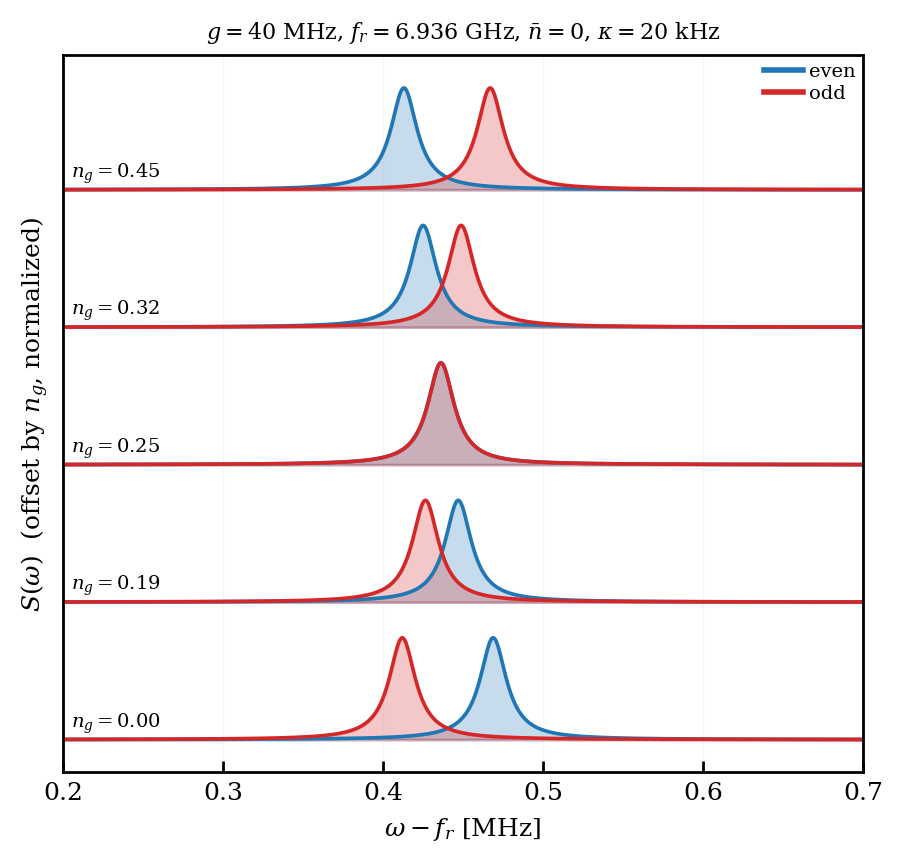

In [24]:
KAPPA_HZ = 20e3                       # resonator linewidth (FWHM) for display
ng_list  = [0.0, 0.19, 0.25, 0.32, 0.45]
detune   = np.linspace(0.20e6, 0.70e6, 1500)   # omega - f_r window [Hz]
omega    = RESONATOR_FREQ_HZ + detune

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4.4, 4.2))
    dy = 1.35
    for j, ng_val in enumerate(ng_list):
        Se = qpd.compute_transmission_lineshape(
            ng_val, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, omega, parity='even',
            n_bar=0, kappa_hz=KAPPA_HZ, n_qubit=15, n_photon=20, charge_cutoff=31)
        So = qpd.compute_transmission_lineshape(
            ng_val, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, omega, parity='odd',
            n_bar=0, kappa_hz=KAPPA_HZ, n_qubit=15, n_photon=20, charge_cutoff=31)
        norm = max(Se.max(), So.max())
        off = j * dy
        ax.fill_between(detune / MHZ, off, off + Se / norm, color='C0', alpha=0.25)
        ax.plot(detune / MHZ, off + Se / norm, color='C0', lw=1.3)
        ax.fill_between(detune / MHZ, off, off + So / norm, color='C3', alpha=0.25)
        ax.plot(detune / MHZ, off + So / norm, color='C3', lw=1.3)
        ax.text(0.205, off + 0.12, f'$n_g={ng_val:.2f}$', fontsize=7)

    ax.set_yticks([])
    ax.set_xlim(detune[0] / MHZ, detune[-1] / MHZ)
    ax.set_xlabel(r'$\omega - f_r$ [MHz]')
    ax.set_ylabel(r'$S(\omega)$  (offset by $n_g$, normalized)')
    ax.set_title(rf'$g=40$ MHz, $f_r=6.936$ GHz, $\bar n=0$, '
                 rf'$\kappa={KAPPA_HZ/1e3:.0f}$ kHz', fontsize=8)
    ax.legend(handles=[Line2D([0], [0], color='C0', lw=2, label='even'),
                       Line2D([0], [0], color='C3', lw=2, label='odd')],
              loc='upper right', fontsize=7)
    ax.grid(alpha=0.25)
plt.show()

### Two faces of hybridization: shift vs. split

The Section 10 spikes and a true doublet are **different** phenomena, and
$S(\omega)$ makes the distinction concrete. Both panels use the same photon
numbers $\bar n$ and the same colors.

**Left — dispersive anticrossing (the Section 10 spikes).** At $n_g=0.19$
(even), the bright resonator transition $|0,n\rangle\to|0,n{+}1\rangle$ meets a
*dark* state $|j,m\rangle$ at high photon number. The final state hybridizes,
but the dark partner carries no $\hat a+\hat a^\dagger$ weight, so the peak
stays **single** and merely **slides toward the bare cavity** as $\bar n$ grows
($\chi$ collapses: $+0.45\to+0.03$ MHz from $\bar n=0\to78$). A longitudinal /
AC-Stark shift — `crossing_detected` does *not* fire.

**Right — transverse vacuum-Rabi resonance.** Tune $f_r$ onto a qubit
transition ($f_r=f_{10}\approx5.37$ GHz). Now the bright excitation itself is
degenerate: at $\bar n=0$, $|0,1\rangle$ and $|1,0\rangle$ mix and *both* carry
probe weight, so $S(\omega)$ is a genuine doublet at $\pm g$. This is the only
true multi-peak structure — and it is special to the vacuum: as $\bar n$ grows
the splitting **washes out and collapses back toward $f_r$** (the bright
same-branch Jaynes–Cummings transitions cluster at $\omega_r$).

So in *both* panels, raising $\bar n$ drives the response toward the bare cavity
— the closed-system precursor of high-power punch-out.

/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2289015277.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_78446/2289015277.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


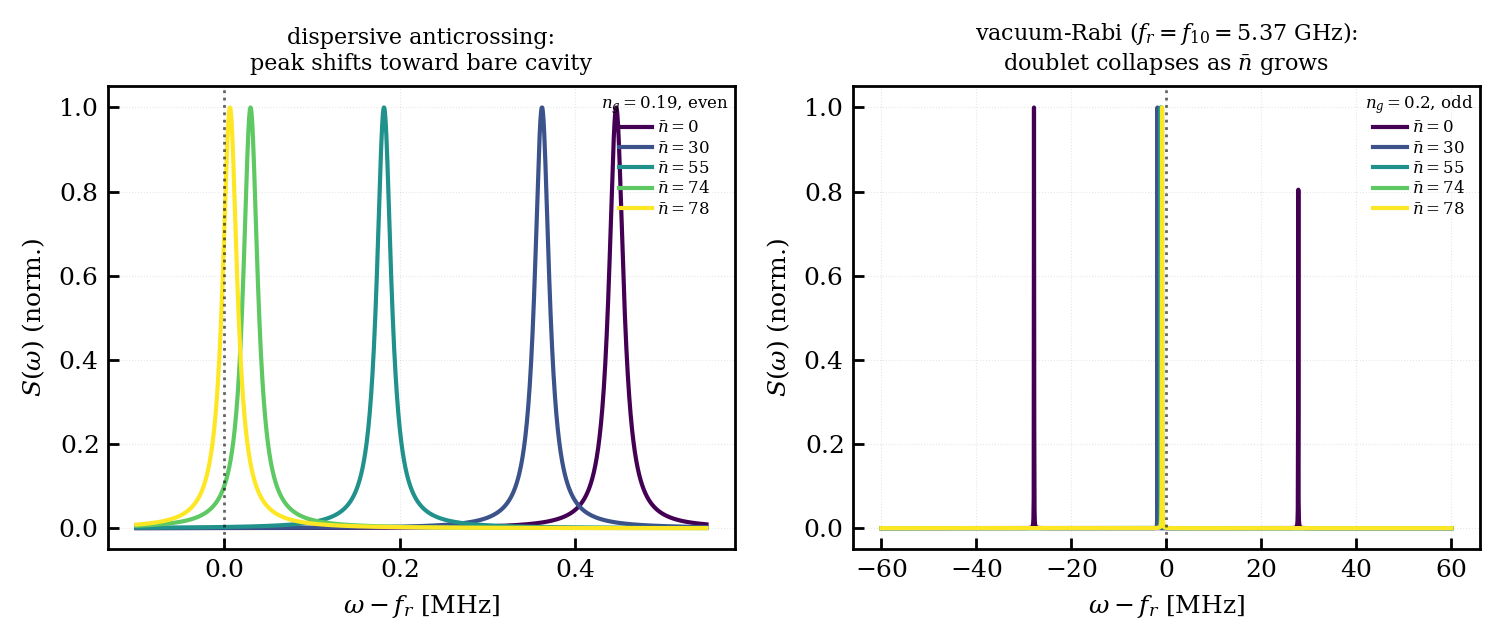

In [28]:
nbars = [0, 30, 55, 74, 78]
cmap = cm.get_cmap('viridis')

with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.6, 3.3))

    # (a) dispersive anticrossing: the single peak SHIFTS with n_bar
    det1 = np.linspace(-0.10e6, 0.55e6, 1600); w1 = RESONATOR_FREQ_HZ + det1
    for j, nb_ in enumerate(nbars):
        S = qpd.compute_transmission_lineshape(
            0.19, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, w1, parity='even',
            n_bar=nb_, kappa_hz=20e3, n_qubit=15, n_photon=100, charge_cutoff=31)
        ax1.plot(det1 / MHZ, S / S.max(), color=cmap(j / (len(nbars) - 1)),
                 lw=1.5, label=f'$\\bar n={nb_}$')
    ax1.axvline(0, color='k', ls=':', lw=1, alpha=0.6)
    ax1.set_xlabel(r'$\omega - f_r$ [MHz]'); ax1.set_ylabel(r'$S(\omega)$ (norm.)')
    ax1.set_title('dispersive anticrossing:\npeak shifts toward bare cavity', fontsize=8)
    ax1.legend(fontsize=6, title='$n_g=0.19$, even', title_fontsize=6, loc="best")
    ax1.grid(alpha=0.25)

    # (b) transverse vacuum-Rabi resonance: SAME n_bar set and colors
    f10 = np.diff(qpd.solve_eigensystem(0.2 + 0.5)[0][:2])[0] / qpd.PLANCK_EV_S
    det2 = np.linspace(-60e6, 60e6, 2000); w2 = f10 + det2
    for j, nb_ in enumerate(nbars):
        S = qpd.compute_transmission_lineshape(
            0.2, COUPLING_G_HZ_S9, f10, w2, parity='odd',
            n_bar=nb_, kappa_hz=20e3, n_qubit=15, n_photon=100, charge_cutoff=31)
        ax2.plot(det2 / MHZ, S / S.max(), color=cmap(j / (len(nbars) - 1)), lw=1.5, label=f'$\\bar n={nb_}$')
    ax2.axvline(0, color='k', ls=':', lw=1, alpha=0.6)
    ax2.set_xlabel(r'$\omega - f_r$ [MHz]'); ax2.set_ylabel(r'$S(\omega)$ (norm.)')
    ax2.set_title(rf'vacuum-Rabi ($f_r=f_{{10}}={f10/GHZ:.2f}$ GHz):'
                  '\ndoublet collapses as $\\bar n$ grows', fontsize=8)
    ax2.legend(fontsize=6, title='$n_g=0.2$, odd', title_fontsize=6, loc="best")
    ax2.grid(alpha=0.25)
    fig.tight_layout()
plt.show()

### What a coherent drive actually sees: Poisson averaging

The per-Fock curves above are *ingredients*, not observables. A coherent
readout tone puts the (linear) resonator in a **coherent state** with a
**Poisson** photon-number distribution $P(n)=e^{-\bar n}\bar n^{n}/n!$ (mean
$\bar n$, spread $\sqrt{\bar n}$). As an **approximation** — *not* a solve of
the driven Hamiltonian — we weight the undriven per-Fock responses by that
distribution,

$$S_{\rm drive}(\omega)=\sum_n P(n;\bar n)\,S_n(\omega)$$

(`compute_transmission_lineshape_poisson`). **Left:** idealized Fock
$|0,n\rangle$ responses (sharp, $\Delta n=0$). **Right:** the Poisson average at
the *same* mean $\bar n$ and colors. Away from the anticrossing (low $\bar n$)
the peak position barely depends on $n$, so the average stays sharp — readout
is clean. Near the anticrossing (mid-range $\bar n$) the $\sqrt{\bar n}$-wide
distribution samples steeply-varying peak positions and the line **smears out**
— so the sharp per-Fock features are *not* what you measure at finite power.

**Reading the bimodal curves.** At some mean $\bar n$ the average looks
*double-peaked*. This is **not** a vacuum-Rabi doublet — it is a *caustic*. The
averaged density goes as $P(n)/|d\chi/dn|$, so weight piles up wherever
$\chi(n)$ is flat. Here $\chi(n)$ is non-monotonic (it dips toward the bare
cavity near $n\approx79$, then recovers), so when the Poisson distribution
straddles that turning point the weight accumulates at *both* stationary
points — the bare-cavity minimum and the recovered dispersive branch — leaving
a dip between them.

**Caveat — this is not a driven-Hamiltonian calculation.** It is an
*incoherent* Poisson sum over undriven Fock responses: a crude stand-in that
captures the photon-number-distribution smearing but **not** field coherences,
the qubit-induced nonlinearity's distortion of the state away from coherent, or
the driven dynamics. Where it shows a bimodal line the *real* system is
genuinely bistable (the onset of punch-out) — so the double peak is at best a
hint of that, not a quantitative prediction. The rigorous spectrum requires the
driven-dissipative master equation — tracked in **issue #20**.

/tmp/claude-501/ipykernel_80538/1829977300.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


/tmp/claude-501/ipykernel_80538/1829977300.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


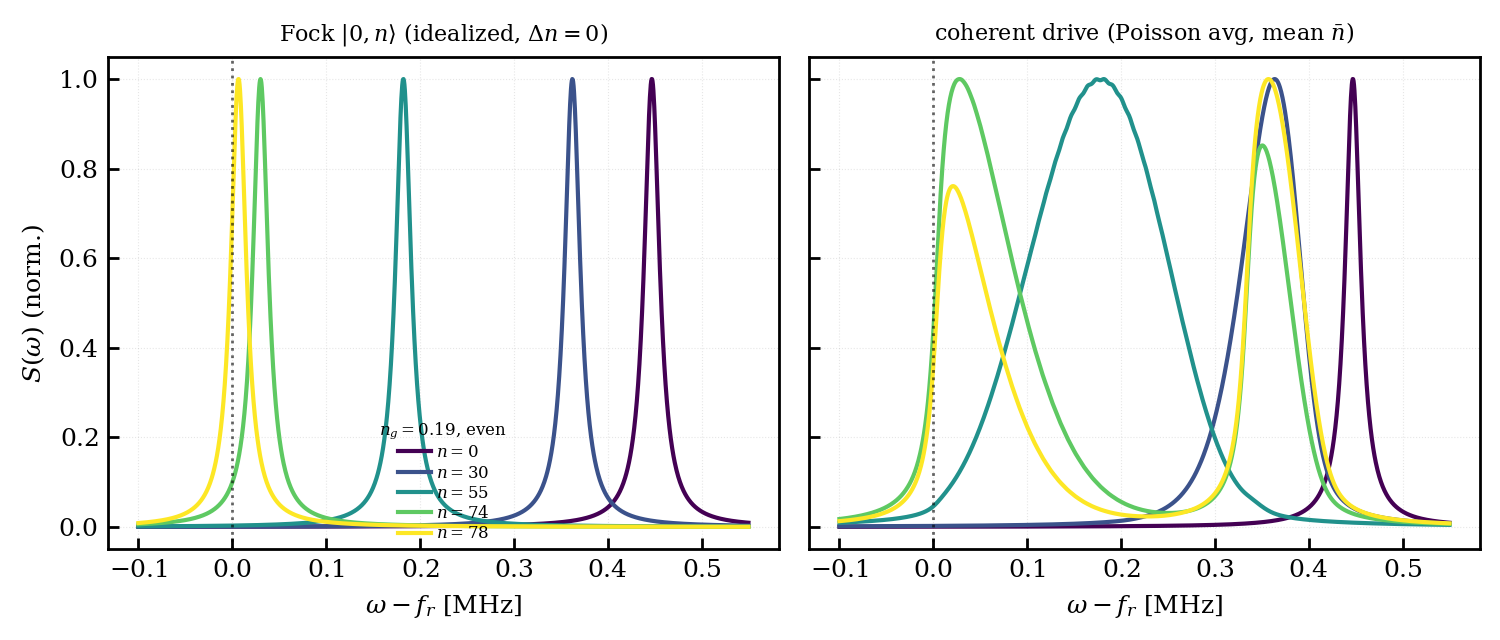

In [2]:
means = [0, 30, 55, 74, 78]
cmap = cm.get_cmap('viridis')
det = np.linspace(-0.10e6, 0.55e6, 1400); w = RESONATOR_FREQ_HZ + det

with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.6, 3.3),
                                   sharex=True, sharey=True)
    for j, m in enumerate(means):
        col = cmap(j / (len(means) - 1))
        Sf = qpd.compute_transmission_lineshape(
            0.19, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, w, parity='even',
            n_bar=m, kappa_hz=20e3, n_qubit=15, n_photon=130, charge_cutoff=31)
        ax1.plot(det / MHZ, Sf / Sf.max(), color=col, lw=1.5, label=f'$n={m}$')
        Sd = qpd.compute_transmission_lineshape_poisson(
            0.19, COUPLING_G_HZ_S9, RESONATOR_FREQ_HZ, w, m, parity='even',
            kappa_hz=20e3, n_qubit=15, n_photon=130, charge_cutoff=31)
        ax2.plot(det / MHZ, Sd / Sd.max(), color=col, lw=1.5)

    for ax, t in [(ax1, r'Fock $|0,n\rangle$ (idealized, $\Delta n=0$)'),
                  (ax2, r'coherent drive (Poisson avg, mean $\bar n$)')]:
        ax.axvline(0, color='k', ls=':', lw=1, alpha=0.6)
        ax.grid(alpha=0.25); ax.set_xlabel(r'$\omega - f_r$ [MHz]')
        ax.set_title(t, fontsize=8)
    ax1.set_ylabel(r'$S(\omega)$ (norm.)')
    ax1.legend(fontsize=6, title='$n_g=0.19$, even', title_fontsize=6)
    fig.tight_layout()
plt.show()

## Summary

| API | Theory | Notes |
|---|---|---|
| `qpd.compute_dispersive_matrix(..., method='perturbative')` | Serniak Eqn. 3 | Default; 2nd-order PT, full coupling (no RWA), single-photon $\chi$. |
| `qpd.compute_dispersive_matrix(..., method='numeric')` | Numerical (circuit-QED) diagonalization | Captures higher-order and Bloch–Siegert effects. Toggle `rwa=True` to recover the Jaynes–Cummings RWA. |
| `qpd.compute_stark_spectrum(...)` | Numerical (circuit-QED) | Returns full dressed map $E(|i,n\rangle)$; photon-number-resolved $\chi_i(n)$ and AC Stark on qubit transitions. |
| `qpd.build_cqed_hamiltonian`, `qpd.solve_cqed_eigensystem` | Numerical (circuit-QED) | Low-level building blocks. |
| `qpd.compute_transmission_spectrum(...)` | Resonator response (label-free) | Transmission peaks from $|\langle f|\hat a+\hat a^\dagger|i\rangle|^2$ over full eigenstates; observed $\chi=f_{\rm peak}-\omega_r$, with `crossing_detected` / `converged` / `n_bar`. |
| `qpd.compute_observed_chi_spectrum(...)` | Resonator response (label-free) | Photon-number-resolved observed $\chi_0(n)$ from one eigensolve; matrix-element analogue of `compute_stark_spectrum`, with per-$n$ `crossing` flags. |
| `qpd.compute_transmission_lineshape(...)` | Resonator response (label-free) | Full $S(\omega)=\sum_f W_f\,\mathcal{L}_\kappa(\omega-\nu_f)$ on a frequency grid for a given $\kappa$; the un-reduced lineshape. |
| `qpd.compute_transmission_lineshape_poisson(...)` | Resonator response (Poisson approx) | Poisson-averaging *approximation* of the coherent-drive spectrum (weighted sum of undriven Fock responses) — **not** a driven-Hamiltonian solve; rigorous version tracked in issue #20. |
| `qpd.plot_observed_peak_vs_ng(...)` | Resonator response (label-free) | Observable parity splitting $|f^o_{\rm pk}-f^e_{\rm pk}|$ vs $n_g$; overlays label $|\Delta\chi_0|$, marks crossings. |

Plotters `plot_dispersive_shift`, `plot_parity_shift_vs_ng`,
`plot_parity_shift_vs_frequency` all accept the same `method=` /
`n_qubit=` / `n_photon=` / `rwa=` switches.
